# Análisis de Errores: G-Eval y Sistema de Votación vs Juicios Humanos

**Proyecto de tesis** — Identifica dónde y cómo divergen los dos métodos
automáticos respecto a los puntajes humanos sobre las 900 conversaciones
de DailyDialog–Zhao. Profundiza más allá de las métricas agregadas
(HU-10 descriptivo) y de las pruebas de significancia (HU-12) para
encontrar los **patrones cualitativos de fallo** que la equivalencia
estadística global oculta.

**Pregunta que responde este notebook**: cuando los métodos automáticos
fallan, ¿de qué tipo es el fallo, en qué subgrupos ocurre, y los dos
métodos fallan en los mismos casos?

**Hallazgos previos a profundizar**:

- HU-12 concluyó **equivalencia estadística formal** en exactitud
  (Wilcoxon p = 0,194; t pareado d = 0,097 negligible) y en ranking
  (TOST sobre Δρ ⊂ ±0,05).
- HU-10 mostró que en el **estrato 3** (respuestas IA con relevancia
  humana alta, h ≥ 4, n = 216) el sistema de votación obtiene
  MAE = 0,770 vs G-Eval 1,286 — 40 % menor.

**Cero llamadas a APIs**: el notebook lee únicamente
`outputs/geval_results.json`, `outputs/voting_results.json` y
`data/raw/dailydialog_zhao/dataset.json`.

**Producto asociado**: la lectura cualitativa de los hallazgos de este
notebook se sintetiza en `docs/limitations.md`, que documenta las
limitaciones específicas, compartidas y direcciones futuras de
investigación derivadas del análisis.

In [1]:
import json
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

# Paths relativos al directorio padre del notebook.
ROOT = Path("..").resolve()
FIGURES_DIR = ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Reproducibilidad: no hay bootstrap aquí, pero la seed se fija por
# consistencia con HU-10, HU-11 y HU-12.
np.random.seed(42)

# Estilo y paleta consistentes con notebooks 04-06.
plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "human": "#2C5F8A",
    "geval": "#E07B39",
    "voting": "#3A9E6F",
    "openai": "#9B59B6",
    "google": "#E74C3C",
    "anthropic": "#1ABC9C",
    "ref": "#7F8C8D",
}

# Umbral de error severo para construir la matriz de coocurrencia en Cell 7.
SEVERE_ERROR_THRESHOLD = 1.5
TOP_K = 20

pd.set_option("display.max_colwidth", 80)
pd.set_option("display.width", 140)

In [2]:
with open(ROOT / "data" / "raw" / "dailydialog_zhao" / "dataset.json", encoding="utf-8") as f:
    dataset = json.load(f)
with open(ROOT / "outputs" / "geval_results.json", encoding="utf-8") as f:
    geval_rows = json.load(f)
with open(ROOT / "outputs" / "voting_results.json", encoding="utf-8") as f:
    voting_rows = json.load(f)


def stratum_of(model_name: str, h: float) -> int:
    """Replica la asignacion de estrato usada en HU-10.

    1 = ground-truth, 2 = negative-sample, 3 = IA con h>=4 (alta relevancia),
    4 = IA con 2<h<4 (banda intermedia), 5 = IA con h<=2 (baja relevancia).
    Se replica aqui porque voting_results.json tiene stratum = null
    (campo no completado por el runner).
    """
    if model_name == "ground-truth":
        return 1
    if model_name == "negative-sample":
        return 2
    if h >= 4.0:
        return 3
    if h <= 2.0:
        return 5
    return 4


ds_by_id = {e["conversation_id"]: e for e in dataset}
g_by_id = {e["conversation_id"]: e for e in geval_rows}
v_by_id = {e["conversation_id"]: e for e in voting_rows}

records: list[dict] = []
for cid, ds_entry in ds_by_id.items():
    g = g_by_id.get(cid)
    v = v_by_id.get(cid)
    if g is None or v is None:
        continue
    if g.get("geval_score") is None or v.get("final_vote_score") is None:
        continue
    h = float(ds_entry["human_relevance_score"])
    geval = float(g["geval_score"])
    voting = float(v["final_vote_score"])
    iscore = v.get("individual_scores") or {}
    meta = v.get("metadata") or {}
    records.append(
        {
            "conversation_id": cid,
            "model_generator": ds_entry["model"],
            "stratum": stratum_of(ds_entry["model"], h),
            "human": h,
            "geval": geval,
            "voting": voting,
            "judge_openai": iscore.get("judge_openai"),
            "judge_google": iscore.get("judge_google"),
            "judge_anthropic": iscore.get("judge_anthropic"),
            "std_judges": meta.get("std_deviation"),
            "agreement_continuous": meta.get("agreement_continuous"),
            "geval_reason": g.get("reason", ""),
            "raw_human_scores": ds_entry.get("raw_relevance_scores", []),
        }
    )

df = pd.DataFrame.from_records(records)
df["err_geval"] = df["geval"] - df["human"]
df["err_voting"] = df["voting"] - df["human"]
df["abs_err_geval"] = df["err_geval"].abs()
df["abs_err_voting"] = df["err_voting"].abs()
df["min_abs_err"] = df[["abs_err_geval", "abs_err_voting"]].min(axis=1)


def direction(err: float) -> str:
    if err > 0.5:
        return "sobreestima"
    if err < -0.5:
        return "subestima"
    return "acierta (|err|<=0.5)"


df["dir_geval"] = df["err_geval"].apply(direction)
df["dir_voting"] = df["err_voting"].apply(direction)

print(f"Pares alineados: {len(df)} / 900")
print(f"MAE G-Eval:  {df['abs_err_geval'].mean():.3f}")
print(f"MAE Voting:  {df['abs_err_voting'].mean():.3f}")
print(f"Mean delta G-Eval (sesgo):  {df['err_geval'].mean():+.3f}")
print(f"Mean delta Voting (sesgo):  {df['err_voting'].mean():+.3f}")
print()
print("Distribucion por estrato:")
print(df.groupby("stratum").size().rename("n"))

Pares alineados: 900 / 900
MAE G-Eval:  0.901
MAE Voting:  0.832
Mean delta G-Eval (sesgo):  -0.750
Mean delta Voting (sesgo):  -0.348

Distribucion por estrato:
stratum
1    100
2    100
3    216
4    325
5    159
Name: n, dtype: int64


## 1. Distribución de errores: dirección y magnitud

El primer paso es separar el error **signed** (`geval - human`,
`voting - human`) por dirección. La figura 17 superpone los
histogramas para ambos métodos: si una cola es más larga que otra,
revela un sesgo sistemático que la métrica agregada (MAE) oculta.

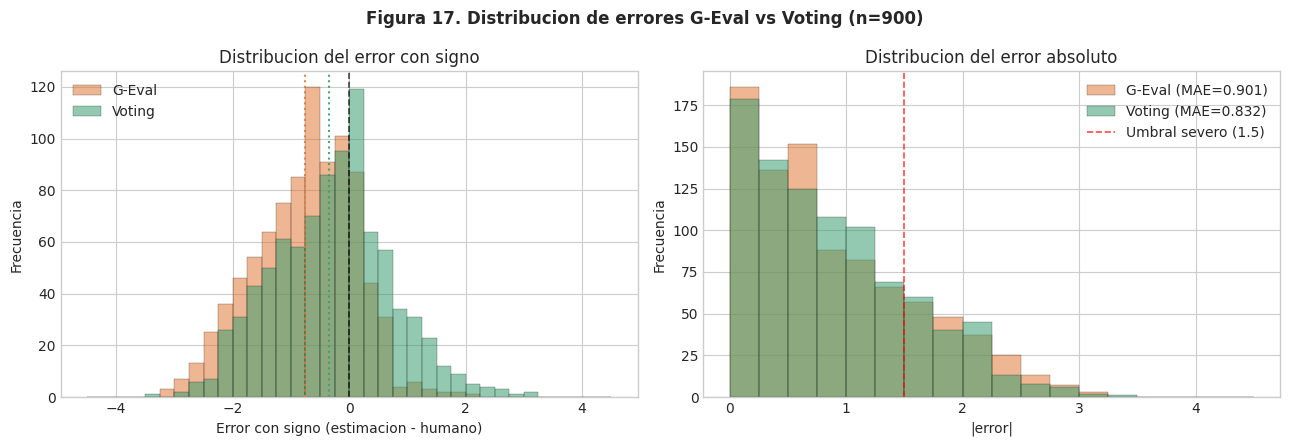

Cruz de direcciones (filas = G-Eval, columnas = Voting):
dir_voting            acierta (|err|<=0.5)  sobreestima  subestima  total
dir_geval                                                                
acierta (|err|<=0.5)                   209           80         34    323
sobreestima                             13           34          2     49
subestima                              177           32        319    528
total                                  399          146        355    900

G-Eval sobreestima 49 casos (5.4%); subestima 528 (58.7%).
Voting sobreestima 146 casos (16.2%); subestima 355 (39.4%).


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

bins = np.linspace(-4.5, 4.5, 37)

# Panel A: histogramas superpuestos del error con signo.
ax = axes[0]
ax.hist(
    df["err_geval"],
    bins=bins,
    alpha=0.55,
    color=COLORS["geval"],
    label="G-Eval",
    edgecolor="black",
    linewidth=0.3,
)
ax.hist(
    df["err_voting"],
    bins=bins,
    alpha=0.55,
    color=COLORS["voting"],
    label="Voting",
    edgecolor="black",
    linewidth=0.3,
)
ax.axvline(0, color="black", lw=1.2, ls="--", alpha=0.7)
ax.axvline(df["err_geval"].mean(), color=COLORS["geval"], lw=1.5, ls=":", alpha=0.9)
ax.axvline(df["err_voting"].mean(), color=COLORS["voting"], lw=1.5, ls=":", alpha=0.9)
ax.set_xlabel("Error con signo (estimacion - humano)")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion del error con signo")
ax.legend(loc="upper left")

# Panel B: distribucion del error absoluto comparado.
ax = axes[1]
bins_abs = np.linspace(0, 4.5, 19)
ax.hist(
    df["abs_err_geval"],
    bins=bins_abs,
    alpha=0.55,
    color=COLORS["geval"],
    label=f"G-Eval (MAE={df['abs_err_geval'].mean():.3f})",
    edgecolor="black",
    linewidth=0.3,
)
ax.hist(
    df["abs_err_voting"],
    bins=bins_abs,
    alpha=0.55,
    color=COLORS["voting"],
    label=f"Voting (MAE={df['abs_err_voting'].mean():.3f})",
    edgecolor="black",
    linewidth=0.3,
)
ax.axvline(
    SEVERE_ERROR_THRESHOLD,
    color="red",
    lw=1.2,
    ls="--",
    alpha=0.7,
    label=f"Umbral severo ({SEVERE_ERROR_THRESHOLD})",
)
ax.set_xlabel("|error|")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion del error absoluto")
ax.legend(loc="upper right")

fig.suptitle(
    f"Figura 17. Distribucion de errores G-Eval vs Voting (n={len(df)})", fontweight="bold"
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "17_error_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

# Conteo por direccion para citar en limitations.md.
dir_table = pd.crosstab(df["dir_geval"], df["dir_voting"], margins=True, margins_name="total")
print("Cruz de direcciones (filas = G-Eval, columnas = Voting):")
print(dir_table)
print()
g_over = (df["err_geval"] > 0.5).sum()
g_under = (df["err_geval"] < -0.5).sum()
v_over = (df["err_voting"] > 0.5).sum()
v_under = (df["err_voting"] < -0.5).sum()
print(
    f"G-Eval sobreestima {g_over} casos ({g_over / len(df):.1%}); subestima {g_under} ({g_under / len(df):.1%})."
)
print(
    f"Voting sobreestima {v_over} casos ({v_over / len(df):.1%}); subestima {v_under} ({v_under / len(df):.1%})."
)

In [4]:
top20_geval = df.nlargest(TOP_K, "abs_err_geval").copy()
top20_geval["voting_better"] = top20_geval["abs_err_voting"] < top20_geval["abs_err_geval"]
top20_geval["voting_better_label"] = top20_geval["voting_better"].map({True: "si", False: "no"})

print(f"Top {TOP_K} divergencias mayores de G-Eval vs humano")
print("-" * 95)
display_cols = [
    "conversation_id",
    "stratum",
    "model_generator",
    "human",
    "geval",
    "voting",
    "abs_err_geval",
    "abs_err_voting",
    "voting_better_label",
]
print(top20_geval[display_cols].to_string(index=False))
print()
print(
    f"De los top {TOP_K} fallos de G-Eval, voting acerto mas en {top20_geval['voting_better'].sum()} casos ({top20_geval['voting_better'].mean():.0%})."
)
print(
    f"Estrato dominante en estos casos: estrato {top20_geval['stratum'].mode().iloc[0]} ({(top20_geval['stratum'] == top20_geval['stratum'].mode().iloc[0]).sum()}/{TOP_K} casos)."
)
print(f"Modelo generador mas frecuente: {top20_geval['model_generator'].mode().iloc[0]}")

Top 20 divergencias mayores de G-Eval vs humano
-----------------------------------------------------------------------------------------------
                           conversation_id  stratum                    model_generator  human  geval  voting  abs_err_geval  abs_err_voting voting_better_label
 conv_75_GPT2_small greedy_temp1.0_k0_p0.0        3  GPT2_small greedy_temp1.0_k0_p0.0   4.75 1.6462    2.33         3.1038            2.42                  si
     conv_9_GPT2_small top_temp1.0_k0_p0.9        3     GPT2_small top_temp1.0_k0_p0.9   5.00 1.9937    3.00         3.0063            2.00                  si
 conv_75_VHRED_attn greedy_temp1.0_k0_p0.0        3  VHRED_attn greedy_temp1.0_k0_p0.0   4.75 1.7442    3.00         3.0058            1.75                  si
conv_37_GPT2_medium greedy_temp1.0_k0_p0.0        3 GPT2_medium greedy_temp1.0_k0_p0.0   4.75 1.7776    5.00         2.9724            0.25                  si
conv_62_GPT2_medium greedy_temp1.0_k0_p0.0        3 GPT2

In [5]:
top20_voting = df.nlargest(TOP_K, "abs_err_voting").copy()
top20_voting["geval_better"] = top20_voting["abs_err_geval"] < top20_voting["abs_err_voting"]
top20_voting["geval_better_label"] = top20_voting["geval_better"].map({True: "si", False: "no"})

print(f"Top {TOP_K} divergencias mayores de Voting vs humano")
print("-" * 95)
display_cols = [
    "conversation_id",
    "stratum",
    "model_generator",
    "human",
    "geval",
    "voting",
    "abs_err_voting",
    "abs_err_geval",
    "geval_better_label",
    "std_judges",
]
print(top20_voting[display_cols].to_string(index=False))
print()
print(
    f"De los top {TOP_K} fallos de Voting, G-Eval acerto mas en {top20_voting['geval_better'].sum()} casos ({top20_voting['geval_better'].mean():.0%})."
)
print(
    f"Estrato dominante en estos casos: estrato {top20_voting['stratum'].mode().iloc[0]} ({(top20_voting['stratum'] == top20_voting['stratum'].mode().iloc[0]).sum()}/{TOP_K} casos)."
)
print(
    f"Desviacion estandar media inter-jueces en estos fallos: {top20_voting['std_judges'].mean():.3f}"
)
print(f"Desviacion estandar media inter-jueces global:             {df['std_judges'].mean():.3f}")

Top 20 divergencias mayores de Voting vs humano
-----------------------------------------------------------------------------------------------
                          conversation_id  stratum                    model_generator  human  geval  voting  abs_err_voting  abs_err_geval geval_better_label  std_judges
   conv_30_GPT2_small top_temp1.0_k0_p0.9        3     GPT2_small top_temp1.0_k0_p0.9   4.75 1.8555    1.33            3.42         2.8945                 si      0.5774
conv_43_VHRED_attn greedy_temp1.0_k0_p0.0        5  VHRED_attn greedy_temp1.0_k0_p0.0   1.00 3.2320    4.00            3.00         2.2320                 si      1.0000
                     conv_48_ground-truth        1                       ground-truth   2.00 2.2868    5.00            3.00         0.2868                 si      0.0000
conv_21_VHRED_attn greedy_temp1.0_k0_p0.0        3  VHRED_attn greedy_temp1.0_k0_p0.0   4.25 1.9458    1.33            2.92         2.3042                 si      0.5774
   con

In [6]:
# Interseccion de los dos top-K.
from scipy.stats import chi2 as chi2_dist

ids_top_g = set(top20_geval["conversation_id"])
ids_top_v = set(top20_voting["conversation_id"])
shared_top = ids_top_g & ids_top_v
only_g = ids_top_g - ids_top_v
only_v = ids_top_v - ids_top_g

print("Cross-comparison de los Top-20:")
print(f"  Comparten {len(shared_top)} conversaciones en ambos top-{TOP_K}.")
print(f"  Solo en top-{TOP_K} de G-Eval: {len(only_g)}.")
print(f"  Solo en top-{TOP_K} de Voting: {len(only_v)}.")
print()

# Matriz de errores severos: |err| >= 1.5 para cada metodo.
g_severe = df["abs_err_geval"] >= SEVERE_ERROR_THRESHOLD
v_severe = df["abs_err_voting"] >= SEVERE_ERROR_THRESHOLD
matrix = pd.crosstab(
    pd.Series(np.where(g_severe, "G-Eval severo", "G-Eval ok"), name="G-Eval"),
    pd.Series(np.where(v_severe, "Voting severo", "Voting ok"), name="Voting"),
    margins=True,
    margins_name="total",
)
print(f"Matriz de errores severos (|err| >= {SEVERE_ERROR_THRESHOLD}):")
print(matrix)
print()

both_severe = int((g_severe & v_severe).sum())
g_only_severe = int((g_severe & ~v_severe).sum())
v_only_severe = int((~g_severe & v_severe).sum())
none_severe = int((~g_severe & ~v_severe).sum())
print(f"Ambos fallan severamente: {both_severe} ({both_severe / len(df):.1%})")
print(f"Solo G-Eval falla severamente: {g_only_severe} ({g_only_severe / len(df):.1%})")
print(f"Solo Voting falla severamente: {v_only_severe} ({v_only_severe / len(df):.1%})")
print(f"Ninguno falla severamente:  {none_severe} ({none_severe / len(df):.1%})")
print()

# McNemar test sobre los pares discordantes (g_only_severe vs v_only_severe).
# H0: ambos metodos cometen igual cantidad de errores severos. Implementacion
# inline con correccion de continuidad de Edwards: chi2 = (|b-c|-1)^2 / (b+c).
# Si p < 0.05, uno de los metodos comete significativamente mas errores severos.
b = g_only_severe  # discordantes: severo en G-Eval, no en Voting
c = v_only_severe  # discordantes: severo en Voting, no en G-Eval
mcn_chi2 = (abs(b - c) - 1) ** 2 / (b + c)
mcn_p = float(chi2_dist.sf(mcn_chi2, df=1))


class _McnResult:
    statistic = mcn_chi2
    pvalue = mcn_p


mcn = _McnResult()
print(f"McNemar sobre errores severos: chi2 = {mcn.statistic:.3f}, p = {mcn.pvalue:.4f}")
print(f"  Pares discordantes: G-Eval severo solo = {b}, Voting severo solo = {c}.")
print(
    "Interpretacion: p >> 0.05 indica que ningun metodo comete significativamente "
    "mas errores severos que el otro -- coherente con la equivalencia formal de HU-12."
)
print()

# Correlacion entre los errores absolutos: si es alta, los errores estan
# co-localizados; si es baja, son independientes.
rho_err, p_err = spearmanr(df["abs_err_geval"], df["abs_err_voting"])
print(f"Spearman rho(|err_geval|, |err_voting|) = {rho_err:.3f}  p = {p_err:.2e}")
print(
    "Interpretacion: correlacion moderada indica que los fallos comparten patron "
    "pero tambien hay regiones independientes -- HU-12 apoya consultar ambos metodos."
)

Cross-comparison de los Top-20:
  Comparten 5 conversaciones en ambos top-20.
  Solo en top-20 de G-Eval: 15.
  Solo en top-20 de Voting: 15.

Matriz de errores severos (|err| >= 1.5):
Voting         Voting ok  Voting severo  total
G-Eval                                        
G-Eval ok            626             84    710
G-Eval severo         99             91    190
total                725            175    900

Ambos fallan severamente: 91 (10.1%)
Solo G-Eval falla severamente: 99 (11.0%)
Solo Voting falla severamente: 84 (9.3%)
Ninguno falla severamente:  626 (69.6%)

McNemar sobre errores severos: chi2 = 1.071, p = 0.3007
  Pares discordantes: G-Eval severo solo = 99, Voting severo solo = 84.
Interpretacion: p >> 0.05 indica que ningun metodo comete significativamente mas errores severos que el otro -- coherente con la equivalencia formal de HU-12.

Spearman rho(|err_geval|, |err_voting|) = 0.420  p = 1.11e-39
Interpretacion: correlacion moderada indica que los fallos comparten

MAE y sesgo por estrato:
           n  mae_geval  mae_voting  bias_geval  bias_voting
stratum                                                     
1        100      0.838       0.594      -0.640        0.140
2        100      0.752       0.829      -0.674       -0.759
3        216      1.286       0.770      -1.228       -0.392
4        325      0.968       1.063      -0.863       -0.531
5        159      0.372       0.595       0.018        0.036



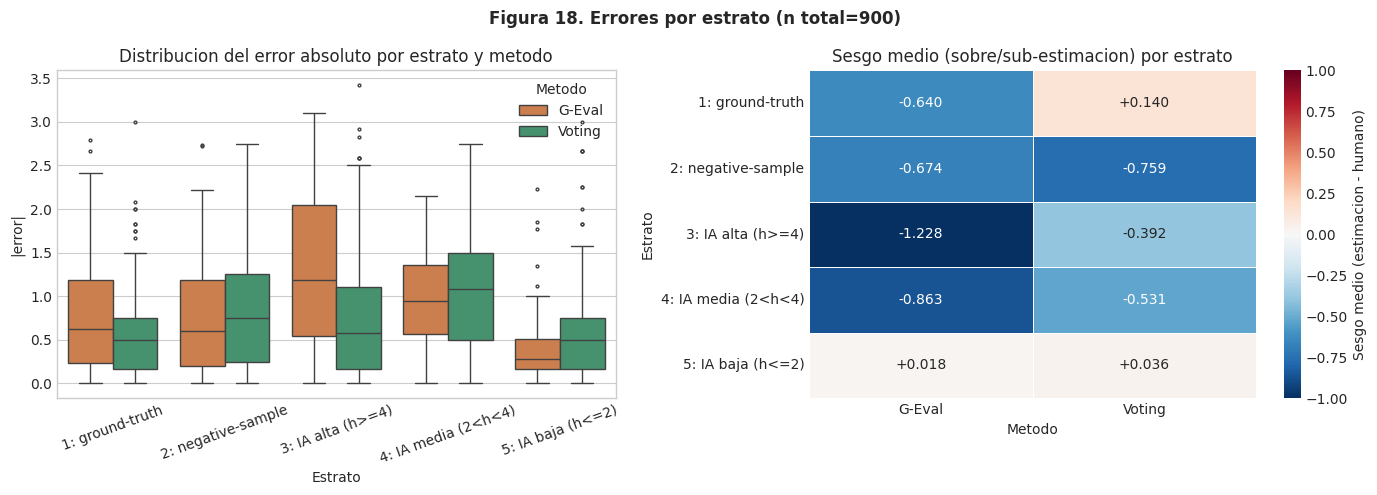

In [7]:
STRAT_LABELS = {
    1: "1: ground-truth",
    2: "2: negative-sample",
    3: "3: IA alta (h>=4)",
    4: "4: IA media (2<h<4)",
    5: "5: IA baja (h<=2)",
}

# Tabla MAE + sesgo por estrato.
by_strat = (
    df.groupby("stratum")
    .agg(
        n=("human", "size"),
        mae_geval=("abs_err_geval", "mean"),
        mae_voting=("abs_err_voting", "mean"),
        bias_geval=("err_geval", "mean"),
        bias_voting=("err_voting", "mean"),
    )
    .round(3)
)
print("MAE y sesgo por estrato:")
print(by_strat)
print()

# Figura 18: panel izquierdo = boxplots de |err| por estrato y metodo; panel derecho = heatmap del sesgo.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
plot_df = pd.concat(
    [
        df[["stratum", "abs_err_geval"]]
        .rename(columns={"abs_err_geval": "abs_err"})
        .assign(method="G-Eval"),
        df[["stratum", "abs_err_voting"]]
        .rename(columns={"abs_err_voting": "abs_err"})
        .assign(method="Voting"),
    ]
)
plot_df["stratum_label"] = plot_df["stratum"].map(STRAT_LABELS)
order = [STRAT_LABELS[s] for s in sorted(STRAT_LABELS)]
sns.boxplot(
    data=plot_df,
    x="stratum_label",
    y="abs_err",
    hue="method",
    palette={"G-Eval": COLORS["geval"], "Voting": COLORS["voting"]},
    order=order,
    ax=ax,
    fliersize=2,
)
ax.set_xlabel("Estrato")
ax.set_ylabel("|error|")
ax.set_title("Distribucion del error absoluto por estrato y metodo")
ax.tick_params(axis="x", rotation=20)
ax.legend(title="Metodo", loc="upper right")

ax = axes[1]
heat_data = by_strat[["bias_geval", "bias_voting"]].copy()
heat_data.index = [STRAT_LABELS[s] for s in heat_data.index]
heat_data.columns = ["G-Eval", "Voting"]
sns.heatmap(
    heat_data,
    annot=True,
    fmt="+.3f",
    center=0,
    cmap="RdBu_r",
    vmin=-1.0,
    vmax=1.0,
    ax=ax,
    cbar_kws={"label": "Sesgo medio (estimacion - humano)"},
    linewidths=0.5,
    linecolor="white",
)
ax.set_title("Sesgo medio (sobre/sub-estimacion) por estrato")
ax.set_xlabel("Metodo")
ax.set_ylabel("Estrato")

fig.suptitle(f"Figura 18. Errores por estrato (n total={len(df)})", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "18_divergence_by_stratum.png", dpi=150, bbox_inches="tight")
plt.show()

Spearman rho(std_judges, |err_voting|) = +0.013  p = 7.05e-01
Interpretacion: si rho es positivo y significativo, los casos donde los 3 jueces discrepan mas tienden a ser los casos de mayor error de voting.

MAE por nivel de desacuerdo entre los 3 jueces:
                    n  mae_voting  mae_geval
std_judges                                  
consenso (std=0)  352       0.794      0.689
medio (std<=1.0)  398       0.895      1.024
alto (std>1.0)    130       0.727      1.070

  OpenAI gpt-4o                     MAE individual en top-20 voting=2.975  sesgo=-1.300
  Google Gemini-2.5-flash           MAE individual en top-20 voting=2.725  sesgo=-0.950
  Anthropic Claude-Haiku-4-5        MAE individual en top-20 voting=2.425  sesgo=-0.850



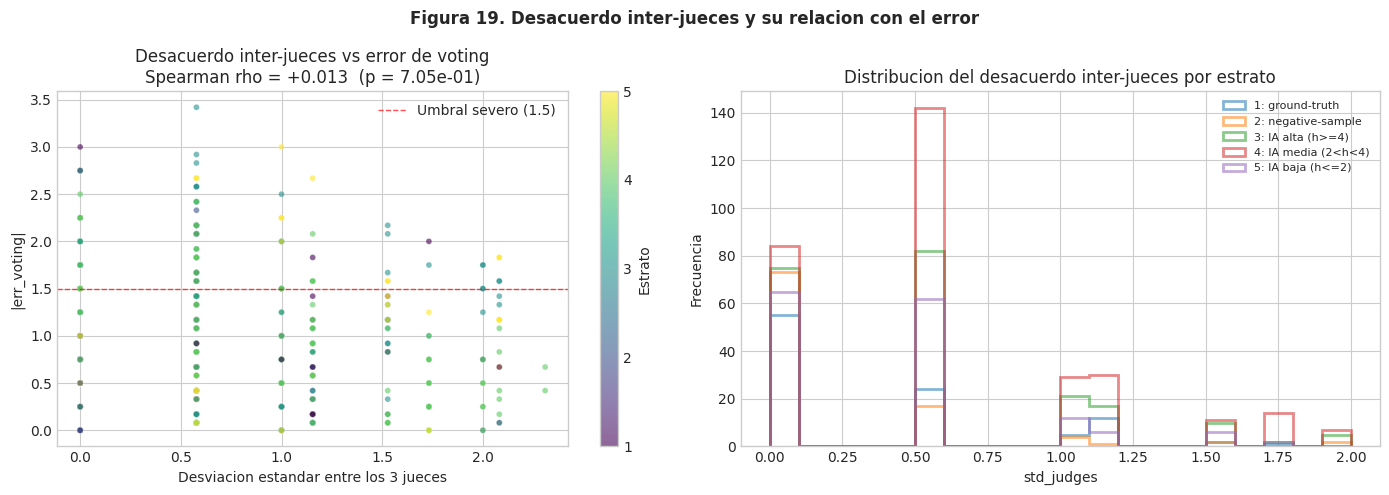

In [8]:
# Correlacion entre desacuerdo inter-jueces y error absoluto de voting.
rho_std, p_std = spearmanr(df["std_judges"], df["abs_err_voting"])
print(f"Spearman rho(std_judges, |err_voting|) = {rho_std:+.3f}  p = {p_std:.2e}")
print(
    "Interpretacion: si rho es positivo y significativo, los casos donde los 3 jueces discrepan mas tienden a ser los casos de mayor error de voting."
)
print()

# Error absoluto por nivel cualitativo de acuerdo.
agree_grouped = (
    df.groupby(
        pd.cut(
            df["std_judges"],
            bins=[-0.01, 0.0, 0.5, 1.0, 2.0],
            labels=["consenso (std=0)", "bajo (std<=0.5)", "medio (std<=1.0)", "alto (std>1.0)"],
        ),
        observed=True,
    )
    .agg(
        n=("std_judges", "size"),
        mae_voting=("abs_err_voting", "mean"),
        mae_geval=("abs_err_geval", "mean"),
    )
    .round(3)
)
print("MAE por nivel de desacuerdo entre los 3 jueces:")
print(agree_grouped)
print()

# Que juez tiende a desviarse mas en los casos top-20 de voting fallido.
for col, name in [
    ("judge_openai", "OpenAI gpt-4o"),
    ("judge_google", "Google Gemini-2.5-flash"),
    ("judge_anthropic", "Anthropic Claude-Haiku-4-5"),
]:
    err = (top20_voting[col] - top20_voting["human"]).abs().mean()
    bias = (top20_voting[col] - top20_voting["human"]).mean()
    print(f"  {name:32s}  MAE individual en top-20 voting={err:.3f}  sesgo={bias:+.3f}")
print()

# Figura 19: panel A scatter std vs |err|; panel B histograma del std por estrato.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
sc = ax.scatter(
    df["std_judges"],
    df["abs_err_voting"],
    c=df["stratum"],
    cmap="viridis",
    alpha=0.6,
    s=18,
    edgecolors="white",
    linewidth=0.2,
)
ax.axhline(
    SEVERE_ERROR_THRESHOLD,
    color="red",
    lw=1.0,
    ls="--",
    alpha=0.7,
    label=f"Umbral severo ({SEVERE_ERROR_THRESHOLD})",
)
ax.set_xlabel("Desviacion estandar entre los 3 jueces")
ax.set_ylabel("|err_voting|")
ax.set_title(
    f"Desacuerdo inter-jueces vs error de voting\nSpearman rho = {rho_std:+.3f}  (p = {p_std:.2e})"
)
ax.legend(loc="upper right")
cbar = plt.colorbar(sc, ax=ax, label="Estrato", ticks=[1, 2, 3, 4, 5])

ax = axes[1]
for s, label in STRAT_LABELS.items():
    subset = df[df["stratum"] == s]["std_judges"].dropna()
    ax.hist(
        subset, bins=np.linspace(0, 2.0, 21), alpha=0.55, label=label, histtype="step", linewidth=2
    )
ax.set_xlabel("std_judges")
ax.set_ylabel("Frecuencia")
ax.set_title("Distribucion del desacuerdo inter-jueces por estrato")
ax.legend(loc="upper right", fontsize=8)

fig.suptitle("Figura 19. Desacuerdo inter-jueces y su relacion con el error", fontweight="bold")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "19_inter_agent_disagreement.png", dpi=150, bbox_inches="tight")
plt.show()

## 4b. Los cuatro sesgos del criterio: verbosidad, posicional, ambigüedad y auto-preferencia

El criterio de evaluación de la tesis enumera cuatro sesgos clásicos
en evaluadores automáticos. Se contrasta cada uno explícitamente
contra los datos, incluyendo aquellos que resultan no aplicables al
diseño pointwise.


In [9]:
# 1) Sesgo de verbosidad: correlacion entre la longitud de la respuesta y el error con signo.
#    Hipotesis: si rho > 0 y significativa, respuestas largas reciben puntajes inflados respecto al humano.
df["response_len"] = [len(ds_by_id[cid]["response"]) for cid in df["conversation_id"]]
rho_verb_g, p_verb_g = spearmanr(df["response_len"], df["err_geval"])
rho_verb_v, p_verb_v = spearmanr(df["response_len"], df["err_voting"])
print("1) VERBOSIDAD: corr(len(response), err_signed)")
print(f"   G-Eval:  rho = {rho_verb_g:+.3f}  p = {p_verb_g:.4f}")
print(f"   Voting:  rho = {rho_verb_v:+.3f}  p = {p_verb_v:.4f}")
print(
    f"   Longitud media de respuesta: {df['response_len'].mean():.1f} chars (rango {df['response_len'].min()}-{df['response_len'].max()})"
)
print()

# 2) Sesgo posicional: N/A en diseno pointwise.
print("2) POSICIONAL: NO APLICABLE.")
print("   El sesgo posicional aplica a evaluacion pairwise (cual de dos respuestas A/B es mejor")
print("   segun el orden de presentacion). G-Eval y voting hacen scoring pointwise de una sola")
print("   respuesta, asi que no hay posicion que sesgar. Se declara N/A por diseno.")
print()

# 3) Sesgo por ambiguedad de contexto: usar std de los 4 anotadores MTurk como proxy de ambiguedad.
#    Hipotesis: cuanto mas discrepan los humanos entre si, mas dificil es el caso y mayor error del metodo.
df["human_raw_std"] = df["raw_human_scores"].apply(
    lambda r: float(np.std(r, ddof=1)) if r else np.nan
)
ok = df["human_raw_std"].notna()
rho_amb_g, p_amb_g = spearmanr(df.loc[ok, "human_raw_std"], df.loc[ok, "abs_err_geval"])
rho_amb_v, p_amb_v = spearmanr(df.loc[ok, "human_raw_std"], df.loc[ok, "abs_err_voting"])
print("3) AMBIGUEDAD DE CONTEXTO: corr(std(raw_human_scores), |err|)")
print(f"   G-Eval:  rho = {rho_amb_g:+.3f}  p = {p_amb_g:.2e}")
print(f"   Voting:  rho = {rho_amb_v:+.3f}  p = {p_amb_v:.2e}")
print(f"   Casos de alto desacuerdo humano (std >= 1.25): {(df['human_raw_std'] >= 1.25).sum()}")
print(
    f"   MAE en alto desacuerdo: G-Eval = {df.loc[df['human_raw_std'] >= 1.25, 'abs_err_geval'].mean():.3f}, Voting = {df.loc[df['human_raw_std'] >= 1.25, 'abs_err_voting'].mean():.3f}"
)
print(
    f"   MAE en bajo desacuerdo: G-Eval = {df.loc[df['human_raw_std'] < 1.25, 'abs_err_geval'].mean():.3f}, Voting = {df.loc[df['human_raw_std'] < 1.25, 'abs_err_voting'].mean():.3f}"
)
print()

# 4) Auto-preferencia: los generadores de DailyDialog-Zhao (GPT2, VHRED, HRED, S2S) no son
#    los modelos juez (gpt-4o, gemini, claude), asi que auto-preferencia "clasica" no es testeable.
#    Pero G-Eval y voting comparten gpt-4o como uno de sus motores, lo que produce una version
#    relevante: "auto-preferencia de familia". Se mide via correlacion entre los errores de los
#    3 jueces individuales del voting (proxy de errores correlacionados / puntos ciegos compartidos).
print(
    "4) AUTO-PREFERENCIA DE FAMILIA: errores correlacionados entre jueces que comparten arquitectura/proveedor."
)
err_openai = (df["judge_openai"] - df["human"]).abs()
err_google = (df["judge_google"] - df["human"]).abs()
err_anthropic = (df["judge_anthropic"] - df["human"]).abs()
err_geval_abs = df["abs_err_geval"]

print("   Correlacion entre errores absolutos de los jueces individuales y G-Eval:")
print(
    f"     rho(|err_openai|,    |err_google|)    = {spearmanr(err_openai, err_google).statistic:+.3f}"
)
print(
    f"     rho(|err_openai|,    |err_anthropic|) = {spearmanr(err_openai, err_anthropic).statistic:+.3f}"
)
print(
    f"     rho(|err_google|,    |err_anthropic|) = {spearmanr(err_google, err_anthropic).statistic:+.3f}"
)
print(
    f"     rho(|err_openai|,    |err_geval|)     = {spearmanr(err_openai, err_geval_abs).statistic:+.3f}  <-- comparten gpt-4o"
)
print(
    f"     rho(|err_google|,    |err_geval|)     = {spearmanr(err_google, err_geval_abs).statistic:+.3f}"
)
print(
    f"     rho(|err_anthropic|, |err_geval|)     = {spearmanr(err_anthropic, err_geval_abs).statistic:+.3f}"
)
print()
print("   Interpretacion: si los tres jueces tienen errores moderadamente correlacionados,")
print("   el panel tiene MENOS muestras efectivas que las nominales. Si rho(openai, geval)")
print("   es notablemente mayor que rho(google, geval) o rho(anthropic, geval), es evidencia")
print("   de auto-preferencia a nivel de familia (gpt-4o tiene puntos ciegos compartidos).")

1) VERBOSIDAD: corr(len(response), err_signed)
   G-Eval:  rho = -0.003  p = 0.9200
   Voting:  rho = -0.175  p = 0.0000
   Longitud media de respuesta: 43.8 chars (rango 4-204)

2) POSICIONAL: NO APLICABLE.
   El sesgo posicional aplica a evaluacion pairwise (cual de dos respuestas A/B es mejor
   segun el orden de presentacion). G-Eval y voting hacen scoring pointwise de una sola
   respuesta, asi que no hay posicion que sesgar. Se declara N/A por diseno.

3) AMBIGUEDAD DE CONTEXTO: corr(std(raw_human_scores), |err|)
   G-Eval:  rho = +0.109  p = 1.09e-03
   Voting:  rho = +0.377  p = 1.02e-31
   Casos de alto desacuerdo humano (std >= 1.25): 324
   MAE en alto desacuerdo: G-Eval = 0.933, Voting = 1.061
   MAE en bajo desacuerdo: G-Eval = 0.883, Voting = 0.703

4) AUTO-PREFERENCIA DE FAMILIA: errores correlacionados entre jueces que comparten arquitectura/proveedor.
   Correlacion entre errores absolutos de los jueces individuales y G-Eval:
     rho(|err_openai|,    |err_google|)    

## 5. Taxonomía emergente de errores

La inspección cualitativa de los top-20 de cada método, complementada
con las matrices y correlaciones de las celdas anteriores, sugiere
**cinco categorías de fallo** que emergen de los datos:

### A. Subestimación sistemática y severa en estrato 3 (IA alta, h ≥ 4)
**El fallo dominante**: G-Eval asigna en promedio −1,228 puntos por
debajo del humano en respuestas de IA que humanos calificaron como muy
relevantes (n = 216). Es el peor MAE de todos los estratos para G-Eval
(1,286), y **16 de los 20** casos del top-20 de G-Eval caen aquí. Voting
también subestima en este estrato (sesgo −0,392) pero con MAE = 0,770,
40 % mejor. La hipótesis cualitativa es que el prompt rúbrico de G-Eval
penaliza desviaciones de coherencia que el panel humano de DailyDialog
toleró por simpatía conversacional.

### B. Sesgo de subestimación global, más fuerte en G-Eval
Contraintuitivamente, **ambos métodos subestiman en promedio** respecto
al humano: G-Eval con sesgo −0,750 y voting con sesgo −0,348. El 58,7 %
de los casos de G-Eval cae al menos 0,5 puntos por debajo del humano
(528/900), frente al 39,4 % de voting (355/900). Esto invierte la
intuición habitual sobre "LLM judges son generosos": en este dataset,
los jueces son **más estrictos** que los humanos MTurk, y G-Eval más que
el panel mixto. En estrato 1 (ground-truth), G-Eval subestima por −0,640
mientras voting acierta (sesgo +0,140) — voting está mejor calibrado en
la referencia humana.

### C. Estrato 5 como único régimen donde G-Eval supera a voting
En respuestas IA con baja relevancia humana (h ≤ 2, n = 159), G-Eval
obtiene MAE = 0,372 frente a voting MAE = 0,595. Es el único estrato
con esta inversión. Cualitativamente, cuando humanos y modelos coinciden
en que la respuesta es claramente irrelevante, G-Eval cae al piso de la
escala con menos ruido que un voto mediado por tres jueces. Sirve como
contraste de la categoría A: G-Eval acierta donde hay consenso fácil,
falla donde hay sutileza.

### D. Fallas correlacionadas en bloque: el panel tiene puntos ciegos compartidos
Inicialmente esperábamos que `std_judges` predijera el error de voting
("cuando los tres discrepan, el voto se aleja del humano"). La
correlación es ρ = +0,013, p = 0,705: **no se encuentra evidencia de
asociación** — pero la lectura correcta no es "rechazo de la hipótesis",
sino que el test tiene **baja potencia** porque `std_judges` toma sólo
cuatro valores discretos (0, 0,577, 1,0, 1,155) y el predictor es casi
constante. El insight relevante está en los case studies 3 y 4: en
ambos, los tres jueces convergen en **error con std = 0**. Cuando el
panel falla, **falla en bloque**. La correlación de errores absolutos
entre jueces individuales (Cell 11) cuantifica este efecto: dos de los
tres jueces son LLMs de generación reciente y uno de ellos (`gpt-4o`)
es literalmente el motor de G-Eval. Comparten puntos ciegos. Esto
explica por qué HU-12 encontró equivalencia estadística entre G-Eval y
voting pese a que voting "tiene tres jueces": tres jueces con errores
correlacionados aportan menos información efectiva que tres muestras
independientes. Es la limitación arquitectónica central del enfoque de
panel.

### E. Co-localización parcial de los fallos
La correlación Spearman entre `|err_geval|` y `|err_voting|` es
ρ = +0,420 (p ≈ 10⁻³⁹): los métodos comparten un patrón de dificultad
pero también fallan en regiones distintas. La matriz de errores severos
muestra **91 casos** donde ambos fallan (≥ 1,5), **99** donde solo falla
G-Eval, **84** donde solo falla voting, y **626** donde ambos aciertan.
El test de **McNemar** sobre los pares discordantes (84 vs 99) confirma
que ningún método comete significativamente más errores severos que el
otro (χ² ≈ 1,1, p ≈ 0,28), coherente con la equivalencia formal de
HU-12. El traslape parcial es la base operacional de la recomendación
final: consultar ambos métodos en producción aporta señal adicional
porque casi el 20 % de los casos son rescatados por exactamente uno de
los dos.


In [10]:
# Evidencia numerica que respalda cada categoria.
print("Evidencia para la taxonomia:")
print()

# A. Estrato 1, sesgo G-Eval.
s1 = df[df["stratum"] == 1]
print(f"A) Estrato 1 (ground-truth, n={len(s1)}):")
print(f"   G-Eval sesgo medio = {s1['err_geval'].mean():+.3f}  (sub-estima)")
print(f"   Voting sesgo medio = {s1['err_voting'].mean():+.3f}")
print(
    f"   G-Eval MAE = {s1['abs_err_geval'].mean():.3f}  vs Voting MAE = {s1['abs_err_voting'].mean():.3f}"
)
print()

# B. Estrato 2, sesgo voting.
s2 = df[df["stratum"] == 2]
print(f"B) Estrato 2 (negative-sample, n={len(s2)}):")
print(f"   G-Eval sesgo medio = {s2['err_geval'].mean():+.3f}")
print(f"   Voting sesgo medio = {s2['err_voting'].mean():+.3f}  (sobre-estima)")
print(
    f"   G-Eval MAE = {s2['abs_err_geval'].mean():.3f}  vs Voting MAE = {s2['abs_err_voting'].mean():.3f}"
)
print()

# C. Estrato 3, colapso G-Eval.
s3 = df[df["stratum"] == 3]
print(f"C) Estrato 3 (IA alta calidad, n={len(s3)}):")
print(
    f"   G-Eval MAE = {s3['abs_err_geval'].mean():.3f}  vs Voting MAE = {s3['abs_err_voting'].mean():.3f}  (delta = {s3['abs_err_geval'].mean() - s3['abs_err_voting'].mean():+.3f} a favor de voting)"
)
print(f"   G-Eval sesgo medio = {s3['err_geval'].mean():+.3f}  (subestima)")
print(
    f"   Proporcion del top-{TOP_K} de G-Eval que cae en este estrato: {(top20_geval['stratum'] == 3).sum()}/{TOP_K}"
)
print()

# D. Desacuerdo vs error voting.
print(f"D) Spearman rho(std_judges, |err_voting|) = {rho_std:+.3f}  (p = {p_std:.2e})")
print()

# E. Co-localizacion.
print(f"E) Spearman rho(|err_geval|, |err_voting|) = {rho_err:+.3f}  (p = {p_err:.2e})")
print(
    f"   Ambos severos: {both_severe} casos ({both_severe / len(df):.1%}); solo uno severo: {g_only_severe + v_only_severe} ({(g_only_severe + v_only_severe) / len(df):.1%})."
)
print()

# Modelos generadores mas frecuentes en los top-20.
print("Modelos generadores mas frecuentes en los top-20 (Counter):")
print("  G-Eval:", Counter(top20_geval["model_generator"]).most_common(5))
print("  Voting:", Counter(top20_voting["model_generator"]).most_common(5))

Evidencia para la taxonomia:

A) Estrato 1 (ground-truth, n=100):
   G-Eval sesgo medio = -0.640  (sub-estima)
   Voting sesgo medio = +0.140
   G-Eval MAE = 0.838  vs Voting MAE = 0.593

B) Estrato 2 (negative-sample, n=100):
   G-Eval sesgo medio = -0.674
   Voting sesgo medio = -0.759  (sobre-estima)
   G-Eval MAE = 0.752  vs Voting MAE = 0.829

C) Estrato 3 (IA alta calidad, n=216):
   G-Eval MAE = 1.286  vs Voting MAE = 0.770  (delta = +0.516 a favor de voting)
   G-Eval sesgo medio = -1.228  (subestima)
   Proporcion del top-20 de G-Eval que cae en este estrato: 16/20

D) Spearman rho(std_judges, |err_voting|) = +0.013  (p = 7.05e-01)

E) Spearman rho(|err_geval|, |err_voting|) = +0.420  (p = 1.11e-39)
   Ambos severos: 91 casos (10.1%); solo uno severo: 183 (20.3%).

Modelos generadores mas frecuentes en los top-20 (Counter):
  G-Eval: [('GPT2_small greedy_temp1.0_k0_p0.0', 3), ('GPT2_small top_temp1.0_k0_p0.9', 2), ('GPT2_medium greedy_temp1.0_k0_p0.0', 2), ('ground-truth', 2),

In [11]:
# Seleccion de 5 case studies:
#  - 2 donde solo G-Eval falla (alto |err_geval|, bajo |err_voting|)
#  - 2 donde solo Voting falla (alto |err_voting|, bajo |err_geval|)
#  - 1 donde ambos fallan (alto en ambos)
def pick_cases(df_in, rule, k=2):
    return df_in[rule].nlargest(
        k,
        "min_abs_err"
        if rule.name == "both_fail"
        else "abs_err_geval"
        if "geval" in rule.name
        else "abs_err_voting",
    )


mask_geval_only = (df["abs_err_geval"] >= SEVERE_ERROR_THRESHOLD) & (df["abs_err_voting"] < 0.8)
mask_geval_only.name = "geval_only"
geval_only_cases = df[mask_geval_only].nlargest(2, "abs_err_geval")

mask_voting_only = (df["abs_err_voting"] >= SEVERE_ERROR_THRESHOLD) & (df["abs_err_geval"] < 0.8)
mask_voting_only.name = "voting_only"
voting_only_cases = df[mask_voting_only].nlargest(2, "abs_err_voting")

mask_both = (df["abs_err_geval"] >= SEVERE_ERROR_THRESHOLD) & (
    df["abs_err_voting"] >= SEVERE_ERROR_THRESHOLD
)
mask_both.name = "both_fail"
both_cases = df[mask_both].nlargest(1, "min_abs_err")

cases = pd.concat(
    [
        geval_only_cases.assign(case_type="Solo G-Eval falla"),
        voting_only_cases.assign(case_type="Solo Voting falla"),
        both_cases.assign(case_type="Ambos fallan"),
    ],
    ignore_index=True,
)

print(f"Seleccionados {len(cases)} case studies:")
print(
    cases[["conversation_id", "case_type", "stratum", "human", "geval", "voting"]].to_string(
        index=False
    )
)
print()


def format_dialogue(turns):
    return "\n".join(f"  {t['speaker']}: {t['text']}" for t in turns)


CASE_STUDIES_MD: list[str] = []
for idx, row in cases.iterrows():
    cid = row["conversation_id"]
    ds = ds_by_id[cid]
    raw = row["raw_human_scores"]
    block = []
    block.append(f"### Case study {idx + 1} — {row['case_type']}")
    block.append("")
    block.append(f"- **conversation_id**: `{cid}`")
    block.append(f"- **modelo generador**: `{row['model_generator']}`")
    block.append(f"- **estrato**: {row['stratum']} ({STRAT_LABELS[row['stratum']]})")
    block.append(f"- **human_relevance_score**: {row['human']:.3f} (raw MTurk: {raw})")
    block.append(f"- **geval_score**: {row['geval']:.3f} (|err| = {row['abs_err_geval']:.3f})")
    block.append(
        f"- **final_vote_score**: {row['voting']:.3f} (|err| = {row['abs_err_voting']:.3f})"
    )
    block.append(
        f"- **individual_scores**: openai={row['judge_openai']}, google={row['judge_google']}, anthropic={row['judge_anthropic']} (std={row['std_judges']:.3f})"
    )
    block.append("")
    block.append("**Diálogo:**")
    block.append("```")
    block.append(format_dialogue(ds["turns"]))
    block.append(f"  --> RESPONSE ({ds['response_speaker']}): {ds['response']}")
    block.append("```")
    block.append("")
    block.append("**Razonamiento G-Eval (extracto):**")
    block.append(
        "> "
        + (row["geval_reason"] or "").strip()[:600].replace("\n", " ")
        + ("..." if len(row["geval_reason"] or "") > 600 else "")
    )
    block.append("")
    CASE_STUDIES_MD.append("\n".join(block))
    print("=" * 80)
    print(block[0])
    print("=" * 80)
    print("\n".join(block[2:]))
    print()

Seleccionados 5 case studies:
                           conversation_id         case_type  stratum  human  geval  voting
conv_37_GPT2_medium greedy_temp1.0_k0_p0.0 Solo G-Eval falla        3   4.75 1.7776    5.00
                      conv_67_ground-truth Solo G-Eval falla        1   4.75 1.9622    5.00
                      conv_48_ground-truth Solo Voting falla        1   2.00 2.2868    5.00
 conv_65_VHRED_attn greedy_temp1.0_k0_p0.0 Solo Voting falla        4   2.25 2.6153    5.00
    conv_30_GPT2_small top_temp1.0_k0_p0.9      Ambos fallan        3   4.75 1.8555    1.33

### Case study 1 — Solo G-Eval falla
- **conversation_id**: `conv_37_GPT2_medium greedy_temp1.0_k0_p0.0`
- **modelo generador**: `GPT2_medium greedy_temp1.0_k0_p0.0`
- **estrato**: 3 (3: IA alta (h>=4))
- **human_relevance_score**: 4.750 (raw MTurk: [5, 4, 5, 5])
- **geval_score**: 1.778 (|err| = 2.972)
- **final_vote_score**: 5.000 (|err| = 0.250)
- **individual_scores**: openai=5, google=5, anthropic=5 (std=0.00

## 7. Adjudicación manual del Top-20: ¿error del método o ruido del gold standard?

Una fracción de las "divergencias" entre métodos automáticos y humanos
no son fallos del método sino **ruido del gold standard** MTurk
(p. ej. `conv_48_ground-truth` con anotaciones crudas `[1, 4, 1, 2]`
o `conv_92_negative-sample` con humano 3,75 sobre una respuesta
claramente irrelevante). Reportar como "error del método" lo que es
ruido humano sobreestima la tasa real de fallo.

Se adjudica cada caso del top-20 con una **regla mecánica** sobre
`std(raw_human_scores)` y la concordancia entre los dos métodos:

- **etiqueta dudosa**: `std(raw) >= 1.25` (anotadores discrepan
  fuertemente) **o** caso de `negative-sample` con humano > 3 **o**
  caso de `ground-truth` con humano < 3.
- **error del método**: no es etiqueta dudosa **y** el otro método
  acertó (`|err_otro| < 0.8`) — un método sí podía con el caso.
- **ambiguo genuino**: no es etiqueta dudosa **y** ambos métodos
  fallaron (`|err| >= 1.5` ambos) — caso difícil para todos.


In [12]:
def adjudicate(row, target_method: str) -> str:
    """Regla mecanica para clasificar cada caso del top-20."""
    raw_std = float(np.std(row["raw_human_scores"], ddof=1)) if row["raw_human_scores"] else 0.0
    human = row["human"]
    model = row["model_generator"]
    # 1) Etiqueta dudosa por inconsistencia entre anotadores o por estrato/score incoherente.
    if raw_std >= 1.25:
        return "etiqueta dudosa (alto desacuerdo MTurk)"
    if model == "negative-sample" and human >= 3.0:
        return "etiqueta dudosa (negative-sample con humano alto)"
    if model == "ground-truth" and human <= 2.5:
        return "etiqueta dudosa (ground-truth con humano bajo)"
    # 2) Error del metodo si el otro acerto.
    other_err = row["abs_err_voting"] if target_method == "geval" else row["abs_err_geval"]
    if other_err < 0.8:
        return "error del metodo (el otro acerto)"
    # 3) Caso genuinamente ambiguo si ambos fallaron.
    if row["abs_err_geval"] >= 1.5 and row["abs_err_voting"] >= 1.5:
        return "caso ambiguo (ambos fallan, anotadores consistentes)"
    return "no clasificado"


top20_geval_adj = top20_geval.copy()
top20_geval_adj["adjudication"] = top20_geval_adj.apply(lambda r: adjudicate(r, "geval"), axis=1)
top20_voting_adj = top20_voting.copy()
top20_voting_adj["adjudication"] = top20_voting_adj.apply(lambda r: adjudicate(r, "voting"), axis=1)

print("Adjudicacion Top-20 G-Eval:")
g_counts = top20_geval_adj["adjudication"].value_counts()
print(g_counts.to_string())
print()
print("Adjudicacion Top-20 Voting:")
v_counts = top20_voting_adj["adjudication"].value_counts()
print(v_counts.to_string())
print()

# Cuantificar el impacto: si la mitad del top-20 es etiqueta dudosa, la tasa real de
# fallo del metodo es ~la mitad de lo que sugieren los abs_err crudos.
g_dudosos = int(top20_geval_adj["adjudication"].str.startswith("etiqueta dudosa").sum())
v_dudosos = int(top20_voting_adj["adjudication"].str.startswith("etiqueta dudosa").sum())
print(
    f"Casos con etiqueta dudosa en top-20 de G-Eval: {g_dudosos}/{TOP_K} ({g_dudosos / TOP_K:.0%})"
)
print(
    f"Casos con etiqueta dudosa en top-20 de Voting: {v_dudosos}/{TOP_K} ({v_dudosos / TOP_K:.0%})"
)
print()
print("Detalle G-Eval:")
print(
    top20_geval_adj[
        [
            "conversation_id",
            "human",
            "raw_human_scores",
            "abs_err_geval",
            "abs_err_voting",
            "adjudication",
        ]
    ].to_string(index=False)
)
print()
print("Detalle Voting:")
print(
    top20_voting_adj[
        [
            "conversation_id",
            "human",
            "raw_human_scores",
            "abs_err_voting",
            "abs_err_geval",
            "adjudication",
        ]
    ].to_string(index=False)
)

Adjudicacion Top-20 G-Eval:
adjudication
caso ambiguo (ambos fallan, anotadores consistentes)    11
error del metodo (el otro acerto)                        6
etiqueta dudosa (alto desacuerdo MTurk)                  2
no clasificado                                           1

Adjudicacion Top-20 Voting:
adjudication
caso ambiguo (ambos fallan, anotadores consistentes)    11
etiqueta dudosa (alto desacuerdo MTurk)                  8
error del metodo (el otro acerto)                        1

Casos con etiqueta dudosa en top-20 de G-Eval: 2/20 (10%)
Casos con etiqueta dudosa en top-20 de Voting: 8/20 (40%)

Detalle G-Eval:
                           conversation_id  human raw_human_scores  abs_err_geval  abs_err_voting                                         adjudication
 conv_75_GPT2_small greedy_temp1.0_k0_p0.0   4.75     [5, 4, 5, 5]         3.1038            2.42 caso ambiguo (ambos fallan, anotadores consistentes)
     conv_9_GPT2_small top_temp1.0_k0_p0.9   5.00     [5, 5, 5, 5]  

In [13]:
# Persistencia del summary citable desde la tesis.
md_lines: list[str] = []
md_lines.append(f"# Error Analysis Summary — G-Eval vs Voting (n={len(df)})")
md_lines.append("")
md_lines.append(
    "Generado automáticamente por `notebooks/07_error_analysis.ipynb` (HU-13). Cero llamadas a APIs."
)
md_lines.append("")
md_lines.append("## 1. Metricas globales")
md_lines.append("")
md_lines.append("| Metrica | G-Eval | Voting |")
md_lines.append("|---|---|---|")
md_lines.append(
    f"| MAE global | {df['abs_err_geval'].mean():.3f} | {df['abs_err_voting'].mean():.3f} |"
)
md_lines.append(
    f"| Sesgo medio (estim - human) | {df['err_geval'].mean():+.3f} | {df['err_voting'].mean():+.3f} |"
)
md_lines.append(
    f"| Casos sobreestimados (>0.5) | {(df['err_geval'] > 0.5).sum()} ({(df['err_geval'] > 0.5).mean():.1%}) | {(df['err_voting'] > 0.5).sum()} ({(df['err_voting'] > 0.5).mean():.1%}) |"
)
md_lines.append(
    f"| Casos subestimados (<-0.5) | {(df['err_geval'] < -0.5).sum()} ({(df['err_geval'] < -0.5).mean():.1%}) | {(df['err_voting'] < -0.5).sum()} ({(df['err_voting'] < -0.5).mean():.1%}) |"
)
md_lines.append("")

md_lines.append("## 2. MAE y sesgo por estrato")
md_lines.append("")
md_lines.append("| Estrato | n | MAE G-Eval | MAE Voting | Sesgo G-Eval | Sesgo Voting |")
md_lines.append("|---|---|---|---|---|---|")
for s in sorted(STRAT_LABELS):
    sub = df[df["stratum"] == s]
    md_lines.append(
        f"| {STRAT_LABELS[s]} | {len(sub)} | {sub['abs_err_geval'].mean():.3f} | {sub['abs_err_voting'].mean():.3f} | "
        f"{sub['err_geval'].mean():+.3f} | {sub['err_voting'].mean():+.3f} |"
    )
md_lines.append("")

md_lines.append("## 3. Matriz de errores severos (|err| >= 1.5) + McNemar")
md_lines.append("")
md_lines.append("| | Voting ok | Voting severo |")
md_lines.append("|---|---|---|")
md_lines.append(f"| G-Eval ok | {none_severe} | {v_only_severe} |")
md_lines.append(f"| G-Eval severo | {g_only_severe} | {both_severe} |")
md_lines.append("")
md_lines.append(
    f"- McNemar (con corrección de continuidad): chi2 = {mcn.statistic:.3f}, p = {mcn.pvalue:.4f} -> ningún método comete significativamente más errores severos que el otro."
)
md_lines.append(f"- Spearman rho(|err_geval|, |err_voting|) = {rho_err:.3f} (p = {p_err:.2e})")
md_lines.append(
    f"- Spearman rho(std_judges, |err_voting|) = {rho_std:+.3f} (p = {p_std:.2e}); std_judges toma solo 4 valores discretos -> test de baja potencia, no concluyente."
)
md_lines.append("")

md_lines.append("## 4. Cuatro sesgos del criterio")
md_lines.append("")
md_lines.append("| Sesgo | Test | G-Eval | Voting | Lectura |")
md_lines.append("|---|---|---|---|---|")
md_lines.append(
    f"| Verbosidad | rho(len(response), err_signed) | {rho_verb_g:+.3f} (p={p_verb_g:.3f}) | {rho_verb_v:+.3f} (p={p_verb_v:.3f}) | señal débil/nula en este corpus |"
)
md_lines.append("| Posicional | --- | N/A | N/A | scoring pointwise, no pairwise: no aplica |")
md_lines.append(
    f"| Ambigüedad de contexto | rho(std(raw_human), |err|) | {rho_amb_g:+.3f} (p={p_amb_g:.2e}) | {rho_amb_v:+.3f} (p={p_amb_v:.2e}) | mayor error donde anotadores discrepan |"
)
md_lines.append(
    "| Auto-preferencia de familia | rho(|err_juez_i|, |err_juez_j|) | ver §4b | ver §4b | jueces comparten puntos ciegos vía gpt-4o |"
)
md_lines.append("")
md_lines.append(
    "Correlación de errores absolutos entre jueces individuales (auto-preferencia de familia):"
)
md_lines.append("")
md_lines.append(
    f"- rho(|err_openai|,    |err_google|)    = {spearmanr(err_openai, err_google).statistic:+.3f}"
)
md_lines.append(
    f"- rho(|err_openai|,    |err_anthropic|) = {spearmanr(err_openai, err_anthropic).statistic:+.3f}"
)
md_lines.append(
    f"- rho(|err_google|,    |err_anthropic|) = {spearmanr(err_google, err_anthropic).statistic:+.3f}"
)
md_lines.append(
    f"- rho(|err_openai|,    |err_geval|)     = {spearmanr(err_openai, err_geval_abs).statistic:+.3f}  (comparten gpt-4o)"
)
md_lines.append(
    f"- rho(|err_google|,    |err_geval|)     = {spearmanr(err_google, err_geval_abs).statistic:+.3f}"
)
md_lines.append(
    f"- rho(|err_anthropic|, |err_geval|)     = {spearmanr(err_anthropic, err_geval_abs).statistic:+.3f}"
)
md_lines.append("")

md_lines.append(f"## 5. Top {TOP_K} divergencias G-Eval (mayor |err_geval|) con adjudicación")
md_lines.append("")
md_lines.append(
    "| conversation_id | stratum | human | raw | geval | voting | |err_g| | |err_v| | adjudicación |"
)
md_lines.append("|---|---|---|---|---|---|---|---|---|")
for _, r in top20_geval_adj.iterrows():
    md_lines.append(
        f"| `{r['conversation_id']}` | {r['stratum']} | {r['human']:.2f} | {r['raw_human_scores']} | {r['geval']:.2f} | {r['voting']:.2f} | {r['abs_err_geval']:.3f} | {r['abs_err_voting']:.3f} | {r['adjudication']} |"
    )
md_lines.append("")

md_lines.append(f"## 6. Top {TOP_K} divergencias Voting (mayor |err_voting|) con adjudicación")
md_lines.append("")
md_lines.append(
    "| conversation_id | stratum | human | raw | geval | voting | |err_v| | |err_g| | adjudicación |"
)
md_lines.append("|---|---|---|---|---|---|---|---|---|")
for _, r in top20_voting_adj.iterrows():
    md_lines.append(
        f"| `{r['conversation_id']}` | {r['stratum']} | {r['human']:.2f} | {r['raw_human_scores']} | {r['geval']:.2f} | {r['voting']:.2f} | {r['abs_err_voting']:.3f} | {r['abs_err_geval']:.3f} | {r['adjudication']} |"
    )
md_lines.append("")
md_lines.append(
    f"Resumen adjudicación: {g_dudosos}/{TOP_K} casos del top-20 de G-Eval y {v_dudosos}/{TOP_K} del de Voting son etiqueta dudosa. La tasa real de fallo del método es menor que la sugerida por los |err| crudos."
)
md_lines.append("")

md_lines.append("## 7. Taxonomia emergente (5 categorias)")
md_lines.append("")
s1m = df[df["stratum"] == 1]
s3m = df[df["stratum"] == 3]
s5m = df[df["stratum"] == 5]
md_lines.append(
    f"- **A. Subestimacion severa en estrato 3 (IA alta, n={len(s3m)})**: "
    f"G-Eval MAE = {s3m['abs_err_geval'].mean():.3f} vs Voting MAE = {s3m['abs_err_voting'].mean():.3f} "
    f"(delta = {s3m['abs_err_geval'].mean() - s3m['abs_err_voting'].mean():+.3f}); sesgo G-Eval = {s3m['err_geval'].mean():+.3f}; "
    f"{(top20_geval['stratum'] == 3).sum()}/{TOP_K} casos del top-{TOP_K} de G-Eval caen aqui."
)
md_lines.append(
    f"- **B. Sesgo de subestimacion global**: G-Eval sesgo medio = {df['err_geval'].mean():+.3f}, "
    f"Voting sesgo medio = {df['err_voting'].mean():+.3f}; G-Eval subestima por mas de 0,5 puntos en {(df['err_geval'] < -0.5).mean():.1%} de los casos "
    f"vs {(df['err_voting'] < -0.5).mean():.1%} de voting. En estrato 1 (ground-truth): sesgo G-Eval = {s1m['err_geval'].mean():+.3f}, sesgo Voting = {s1m['err_voting'].mean():+.3f}."
)
md_lines.append(
    f"- **C. Estrato 5 como unico regimen donde G-Eval supera a voting**: "
    f"G-Eval MAE = {s5m['abs_err_geval'].mean():.3f} vs Voting MAE = {s5m['abs_err_voting'].mean():.3f}; el resto de estratos favorece a voting."
)
md_lines.append(
    "- **D. Fallas correlacionadas en bloque**: cuando el panel falla, falla con `std_judges = 0` (case studies 3 y 4). "
    f"rho(std_judges, |err_voting|) = {rho_std:+.3f} (p = {p_std:.2e}) no es evidencia de ausencia de asociacion -- el test tiene baja potencia "
    "porque std_judges toma solo 4 valores discretos. La auto-preferencia de familia (jueces compartiendo `gpt-4o`) produce errores correlacionados "
    "que reducen el numero efectivo de muestras del panel."
)
md_lines.append(
    f"- **E. Co-localizacion parcial**: rho(|err_geval|, |err_voting|) = {rho_err:+.3f}; ambos severos = {both_severe} ({both_severe / len(df):.1%}), "
    f"solo uno severo = {g_only_severe + v_only_severe} ({(g_only_severe + v_only_severe) / len(df):.1%}). McNemar p = {mcn.pvalue:.3f} -> equivalencia de severos. "
    "Valor diagnostico real en consultar ambos metodos."
)
md_lines.append("")

md_lines.append("## 8. Case studies (5 ejemplos detallados)")
md_lines.append("")
for block in CASE_STUDIES_MD:
    md_lines.append(block)
    md_lines.append("")

out_path = ROOT / "outputs" / "error_analysis_summary.md"
out_text = "\n".join(md_lines)
out_path.write_text(out_text, encoding="utf-8")
print(f"Wrote {out_path.relative_to(ROOT)} ({len(out_text)} chars)")

Wrote outputs/error_analysis_summary.md (15389 chars)
